# Analysis Notebook for Radio Star scans using BigDish

dsheen 2025-10-02

The following is a notebook for analysis of radio star scans measured using scan_radio_star.py. Over the course of the notebook we will import the log files, perform rfi-robust processing of the measured data, and use the result to estimate calibrator curves and the telescope sensitivity over the full protected band.

The results of this analysis for a known reference star can then be used to perform wideband calibration of scans of unknown sources.

## 1. Manual Generation of Radio Star Flux Curves

In [1]:
import numpy as np
import scipy as sc
import astropy.units as u
import astropy.constants as const
import matplotlib.pyplot as plt

### Create a Nice Dictionary of Radio Stars we have Good Published Measurements for
use sources from

"An Accurate Flux Density Scale from 50MHz to 50GHz"

R. A. Perley and B. J. Butler National Radio Astronomy Observatory, P.O. Box O, Socorro, NM 87801, USA; RPerley@nrao.edu, BButler@nrao.edu

https://iopscience.iop.org/article/10.3847/1538-4365/aa6df9/pdf

so that we know we have good flux models for them. Only use relatively bright ones that are easy to find. Also save flux coefficents for them from table 6 so we can use this equation

$log(S)=a_0 +a_1log(f)+a_2[log(f)]^2 +a_3[log(f)]^3+ $.... for f in GHz and S in Jy

In [2]:
radio_stars = {}

radio_stars['3C48'] = {'coords':(24.42208192967, 33.15974455245), 
                       'coefficients' : np.array([1.3253, -0.7553,-0.1914,0.0498])}

radio_stars['FornaxA'] = {'coords':(50.6741208, -37.2082), 
                       'coefficients' : np.array([2.2175, -0.6606])}

radio_stars['3C123'] = {'coords':(69.26823064375, 29.67050498975), 
                       'coefficients' : np.array([1.8017, -0.7884, -0.1035, -0.0248, 0.0090])}

radio_stars['3C138'] = {'coords':(80.29119151075, 16.63945876275), 
                       'coefficients' : np.array([1.0088, -0.4981, -0.1552, -0.0102, 0.0223])}

radio_stars['PictorA'] = {'coords':(79.95717888494, -45.77884796187), 
                       'coefficients' : np.array([1.9380, -0.7470, -0.0739])}

radio_stars['TaurusA'] = {'coords':(83.6324, 22.0174), 
                       'coefficients' : np.array([2.9516, -0.2173, -0.0473, -0.0674]),
                    'beamwidth_correction' : 4.6}

radio_stars['3C147'] = {'coords':(85.65057457125, 49.852009364972), 
                       'coefficients' : np.array([1.4516, -0.6961, -0.2007, 0.0640, -0.0464, 0.0289])}

radio_stars['3C196'] = {'coords':(123.40023382088, 48.21740137945), 
                       'coefficients' : np.array([1.2872, -0.8530, -0.1534, -0.0200, 0.0201])}

radio_stars['HydraA'] = {'coords':(139.52361869175, -12.095501689528), 
                       'coefficients' : np.array([1.7795, -0.9176, -0.0843, -0.0139, 0.0295])}

radio_stars['VirgoA'] = {'coords':(187.70593076725, 12.391123246083), 
                       'coefficients' : np.array([2.4466, -0.8116, -0.0483]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C286'] = {'coords':(202.78453479432, 30.50915558099), 
                       'coefficients' : np.array([1.2481, -0.4507, -0.1798, 0.0357])}

radio_stars['3C295'] = {'coords':(212.836, 52.2025), 
                       'coefficients' : np.array([1.4701, -0.7658, -0.2780, -0.0347, 0.0399])}

radio_stars['HerculesA'] = {'coords':(252.78328611990997, 4.99320753652), 
                       'coefficients' : np.array([1.8298, -1.0247, -0.0951])}

radio_stars['3C353'] = {'coords':(260.11736689063, -0.9796062372), 
                       'coefficients' : np.array([1.8627, -0.6938, -0.0998, -0.0732])}

radio_stars['3C380'] = {'coords':(277.38242072207, 48.74615560247), 
                       'coefficients' : np.array([1.2320, -0.7909, 0.0947, 0.0976, -0.1794, -0.1566])}

radio_stars['CygnusA'] = {'coords':(299.868152368208, 40.733915897917), 
                       'coefficients' : np.array([3.3498, -1.0022, -0.2246, 0.0227, 0.0425]),
                         'beamwidth_correction' : 2.5}

radio_stars['3C444'] = {'coords':(333.6073, -17.0267472), 
                       'coefficients' : np.array([1.1064, -1.0052, -0.0750, -0.0767])}

radio_stars['CassiopeiaA'] = {'coords':(350.8584, 58.8113), 
                        'coefficients' : np.array([3.3584, -0.7518, -0.0347, -0.0705]),
                        'beamwidth_correction' : 4.6}

radio_stars['Orion'] = {'coords':(83.8201, -5.3876), 
                       'coefficients' : np.array([2.705, -0.204]),
                       'beamwidth_correction' : 4.6}

In [3]:
def get_flux(star,f):
    '''
    star: str, name of star correcponding to dictinary entry key
    f: frequency or frequencies at which to compute flux
    '''
    
    a = radio_stars[star]['coefficients']
    logfreq = np.log10(f.to(u.GHz).value)
    
    
    logS = np.zeros_like(logfreq)
    for i in range(len(a)):
        logS += a[i]*np.power(logfreq,i)

    S = np.power(10,logS)*u.Jy
    return S

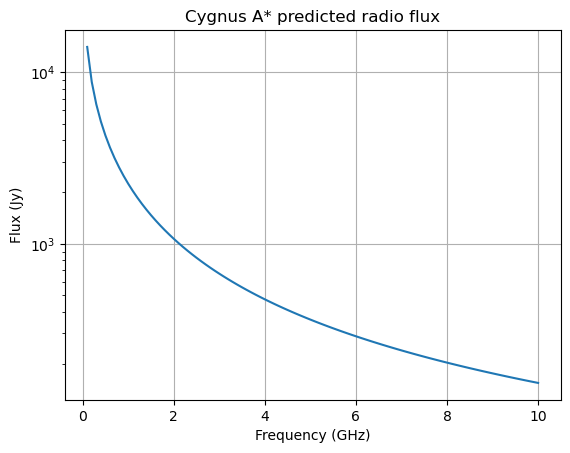

In [4]:
freqs = np.linspace(0.1,10,100)*u.GHz

plt.figure()
plt.semilogy(freqs,get_flux('CygnusA',freqs))
plt.ylabel("Flux (Jy)")
plt.xlabel("Frequency (GHz)")
plt.title("Cygnus A* predicted radio flux")
plt.grid()
plt.show()

### Antenna Parameters and Corrections

from the corrections in RECOMMENDATION ITU-R S.733-2

$\frac{G}{T} = \frac{8\pi k (r-1)}{\lambda^2 \Phi(f)}$

where $r = \frac{P_n + P_{st}}{P_n} = \frac{T_{sys} + T_{st}}{T_{sys}}$ and $\Phi(f)$ is the flux in $Wm^{-2}Hz^{-1}$ 


corrrection factor C2 is included for the angular extent of radio stars vs the beam width in equation 3

$(G/ T)_c = G/T + C1 + C2 + C3$

where C3 is only applicable to Cas A, C1 is a correction for atmospheric loss (which we shall ignore because I typically count that as part of G/T) and so C2 is the only thing that matters


$C2 \approx -10log_{10}\left[\frac{ABS \left( 1-e^{-\chi^2} \right)}{\chi^2}\right]$ in dB

where $\chi_{CygA} \approx \frac{2.5}{1.2012 \theta_{3dB} \times 60}$

and $\chi_{most other things} \approx \frac{4.6}{1.2012 \theta_{3dB} \times 60}$

In [5]:
def get_C2(star,Theta):
    '''
    star is name of star in dictionary
    Theta is half power beamwidth in degrees
    freq is frequency
    
    '''
    Chi = radio_stars[star]['beamwidth_correction']/(1.2012*Theta.to(u.degree).value*60)
    C2 = -10*np.log10(np.abs(1-np.exp(-Chi**2))/Chi**2)
    return C2

## 2. Import Log Data from Scan of Radio Star

Before we can do anything with the actual RF samples, we need to know where the telescope was pointed at what time and what the calibrator states were. for this we need to ingest and process the log file since we do not yet have a mechanism for adding this to the drf metadata during the recording.

the size of the files makes it impractical to keep any in the github so you will need to get your own. the DRF top directory and the logfile should be in the same folder

In [6]:
import os
import sys
import csv
from datetime import datetime, timezone
import pandas as pd

### Get File Information

In [7]:
#observation directory path
#observation_directory = "/home/dsheen/temp_rf_data/cygnusA_2025-10-01_scan/"
observation_directory = "/data/cygnus_2025-10-01"

In [8]:
#grab logfile and drf file paths
files = os.listdir(observation_directory)

for file in files:
    if file.split('.')[-1] == 'log':
        logfile = file
        print(f"found log file {logfile}")
    else: #see if it's the drf directory
        try:
            subdirs = os.listdir(os.path.join(observation_directory, file))
            if 'LHCP' in subdirs or 'RHCP' in subdirs: #then this is probably the drf top directory
                drf_directory = file
                print(f"found drf directory {drf_directory}")
        except:
            print(f"skipping {file}. File does not appear to be digital_rf or logfile.")

found log file 2025-10-02T00:56:29.283430Z_radec_299.87_299.87.log
found drf directory cygnusA_2025-10-01-test2


### Read in the log data

In [9]:
scan_target_commands = []
scan_settling_times = []
scan_calibrator_transitions = []
telescope_positions = []

with open(os.path.join(observation_directory,logfile), 'r') as file:
    logdata = csv.reader(file)

    for row in logdata:
        #splitup by info type and save into python variables and lists

        #####################
        # header info
        #####################
        if row[0].strip() == "scan_coords":
            scan_coord_frame = row[1].strip() #coordinate system
        elif row[0].strip() == "scan_center":
            scan_center = np.array([float(row[i].strip()) for i in range(1,len(row))]) #scan center point
        elif row[0].strip() == "extents":
            extents = np.array([float(row[i].strip()) for i in range(1,len(row))]) #max range of scan from center point
        elif row[0].strip() == "steps":
            steps = np.array([float(row[i].strip()) for i in range(1,len(row))]) #step between points in both axes
        elif row[0].strip() == "num_points":
            num_points = int(row[1].strip()) #number of points in scan
        elif row[0].strip() == "integration_time":
            integration_time = float(row[1].strip()) #time in seconds to integrate after calibration period
        elif row[0].strip() == "cal_time":
            cal_time = float(row[1].strip()) #time for calibrator to be enabled on each channel

        ##########################
        # actual scan timing data
        ##########################
        elif row[0].strip() == "target_point":
            #append command time and coordinates
            scan_target_commands.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                         'pos' : np.array([float(row[3].strip()),float(row[4].strip())])})

        elif row[0].strip() == "position":
            #telescope reported position time, coords, velocities
            telescope_positions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')), 
                                        'pos' : np.array([float(row[2].strip()),float(row[3].strip())]), 
                                        'vel' : np.array([float(row[4].strip()),float(row[5].strip())])})
        elif row[0].strip() == "settled":
            #time when telescope has settled to target point
            scan_settling_times.append(datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')))
        elif row[0].strip() == "calibrator_state":
            #calibrator state timing info
            scan_calibrator_transitions.append({'time': datetime.fromisoformat((row[1].strip()).replace('Z', '+00:00')),
                                                'state': int(row[2].strip())})
        else: #something weird happened
            print(f"unrecognized line starting with {row[0].strip()}! Is file correct?")



print(f"scan contains {num_points} points centered about {scan_coord_frame} coordinates {scan_center}")
#telescope_positions = pd.DataFrame(telescope_positions)
#print(telescope_positions)

scan contains 225 points centered about radec coordinates [299.869  40.739]


### Manipulate this into a nicer format with a signle entry for each point telling us what segments of data are what

In [10]:
scan_points_info = []

#get an array of position timestamps for subsequent use
telescope_position_times = np.array([point['time'].timestamp() for point in telescope_positions])
telescope_position_coords = np.array([point['pos'] for point in telescope_positions])

def get_pointing_time_inices(bounds):
    tmin = bounds[0].timestamp()
    tmax = bounds[1].timestamp()
    imin = np.where(telescope_position_times>=tmin)[0][0]
    imax = np.where(telescope_position_times>=tmax)[0][0]
    return imin,imax

def get_mean_pointing_error(bounds, point):
    """return telescope mean error fromm target"""
    imin,imax = get_pointing_time_inices(bounds)
    positions = telescope_position_coords[imin:imax]
    errors = np.sqrt(np.sum(np.power(positions - point,2),axis=1))
    
    return np.mean(errors)


for i in range(num_points):
    scan_target_coords = scan_target_commands[i]["pos"]
    settling_time = scan_settling_times[i]
    cal_info = scan_calibrator_transitions[3*i:3*i+3]

    if i+1 ==num_points:
        end_time = telescope_positions[-1]["time"]
    else:
        end_time = scan_target_commands[i+1]["time"]

    cal_1_bounds = [cal_info[0]['time'], cal_info[1]['time']]
    cal_2_bounds = [cal_info[1]['time'], cal_info[2]['time']]
    cal_off_bounds = [cal_info[2]['time'], end_time]

    #get nominal pointing errors for these time ranges
    
    #cal1_timestamps 

    scan_points_info.append({'pos' : scan_target_coords,
                             'cal_1_bounds' : cal_1_bounds,
                             'cal_2_bounds' : cal_2_bounds,
                             'cal_off_bounds' : cal_off_bounds,
                             'cal_1_pos_error' : get_mean_pointing_error(cal_1_bounds, scan_target_coords),
                             'cal_2_pos_error' : get_mean_pointing_error(cal_2_bounds, scan_target_coords),
                             'cal_off_pos_error' : get_mean_pointing_error(cal_off_bounds, scan_target_coords),
                            })
    
scan_points_info = pd.DataFrame(scan_points_info)

print(scan_points_info.iloc[0])

pos                                                  [294.619, 35.489]
cal_1_bounds         [2025-10-02 00:56:36+00:00, 2025-10-02 00:56:3...
cal_2_bounds         [2025-10-02 00:56:38+00:00, 2025-10-02 00:56:4...
cal_off_bounds       [2025-10-02 00:56:40+00:00, 2025-10-02 00:56:4...
cal_1_pos_error                                               0.021776
cal_2_pos_error                                               0.032762
cal_off_pos_error                                             0.018212
Name: 0, dtype: object


## 3. Digital RF data import and processing

pull in drf data, get metadata about frequency, sample rate etc. And process the data for each point into spectra for the different calibrator states 

In [11]:
import digital_rf as drf
import multiprocessing
from functools import partial

### Start by getting metadata

In [107]:
rf_data_path = os.path.join(observation_directory,drf_directory)
channels = ["RHCP","LHCP"]

In [13]:
dio = drf.DigitalRFReader(rf_data_path)
sr = dio.get_properties(channels[0])["samples_per_second"]
bounds = dio.get_bounds(channels[0])

dt_start = datetime.fromtimestamp(float(bounds[0] / sr), tz=timezone.utc,)
dt_stop = datetime.fromtimestamp(float(bounds[1] / sr), tz=timezone.utc)

metadata = dio.read_metadata(bounds[0],bounds[0]+1, channels[0])
metadata_key = list(metadata.keys())[0]
radio_metadata = metadata[metadata_key]
cf = radio_metadata['center_frequencies'][0]

print(f"Digital RF data has bounds {dt_start.isoformat()}, {dt_stop.isoformat()}")
print(f"sample rate {sr/1e6} MHz, center frequency {cf/1e6} MHz")

Digital RF data has bounds 2025-10-02T00:56:31+00:00, 2025-10-02T01:50:17+00:00
sample rate 25.0 MHz, center frequency 1413.5 MHz


### User Settings for spectrum slicing

In [44]:
num_frequency_points = 1024

slicelen = 0.1 #approx fft slice time in seconds for the fft computation to not be truly ridiculous 
#will be averaged anyway so just a computation efficincy thing
num_processes = 16

### Define a not completely insane multithreaded FFT processor

In [15]:
def calculate_welch_slice(channel, samples_per_slice, start_sample):
        '''
        Calculate the welch method spectrogram for the given data slice
        '''

        try:
            data = dio.read_vector(
                start_sample, samples_per_slice, channel, 0
            )
        except IOError:
            print(
                "IO Error for channel {0}:{1} start sample {2}".format(
                    channel,
                    start_sample,
                )
            )
            # handle data gaps better
            data = np.empty(samples_per_slice, np.complex64)
            data[:] = np.nan

        #actually handle the welch operation

        try:
            freq_axis, psd_data = sc.signal.welch(
                data,
                fs=float(sr),
                nperseg=num_frequency_points,
                detrend=False,
                scaling="density",
                return_onesided=False,
                average='median'
            )
        except Exception:
            traceback.print_exc(file=sys.stdout)

        #sti_psd_data = np.real(
        #    10.0 * np.log10(np.abs(sc.fft.fftshift(psd_data)) + 1e-20)
        #    )  # 1e-20 is added to prevent divide by zero issues with logarithm

        
        sti_psd_data = np.real(np.abs(sc.fft.fftshift(psd_data)))
        #how the time of the slice is defined is perhaps open to debate
        sti_time = (start_sample + samples_per_slice / 2) / sr
        #sti_time = (start_sample) / self.sample_rate

        return sti_psd_data, sc.fft.fftshift(freq_axis), sti_time

def process_data_spectrum(start_sample, end_sample, channel):
    samples_per_slice = int(sr*slicelen/num_frequency_points)*num_frequency_points
    start_samples = np.arange(start_sample,end_sample,samples_per_slice)

    pool = multiprocessing.Pool(processes=num_processes)
    welch_slice = partial(calculate_welch_slice, channel, samples_per_slice)

    outputs = pool.map(welch_slice, start_samples)

    pool.close()
    pool.join()

    sti_psd_data = outputs[0][0]
    freq_axis = outputs[0][1]

    for i in range(1,len(start_samples)):
        sti_psd_data += outputs[i][0]

    sti_psd_data = sti_psd_data/len(start_samples)
    return sti_psd_data, freq_axis

### Process spectra for each point

In [39]:
point_spectra = []

for i in range(num_points):
    print(f" working on point {i}")
    point_info = scan_points_info.iloc[i]
    
    cal_timing_margin = 0.01
    cal_1_sample_bounds = [int(point_info['cal_1_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_1_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_2_sample_bounds = [int(point_info['cal_2_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_2_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    cal_off_sample_bounds = [int(point_info['cal_off_bounds'][0].timestamp()*sr + cal_timing_margin*sr),
                            int(point_info['cal_off_bounds'][1].timestamp()*sr - cal_timing_margin*sr)]
    
    # just hard code this because it makes building the arrays a little easier
    RHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[0])
    RHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[0])
    RHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[0])

    LHCP_cal_1_psd, freq_axis = process_data_spectrum(cal_1_sample_bounds[0], cal_1_sample_bounds[1], channels[1])
    LHCP_cal_2_psd, freq_axis = process_data_spectrum(cal_2_sample_bounds[0], cal_2_sample_bounds[1], channels[1])
    LHCP_cal_off_psd, freq_axis = process_data_spectrum(cal_off_sample_bounds[0], cal_off_sample_bounds[1],channels[1])

    point_spectra.append({"frequencies" : freq_axis + cf,
                          "RHCP" : [RHCP_cal_off_psd, RHCP_cal_1_psd, RHCP_cal_2_psd],
                          "LHCP" : [LHCP_cal_off_psd, LHCP_cal_1_psd, LHCP_cal_2_psd]})

point_spectra = pd.DataFrame(point_spectra)

 working on point 0
 working on point 1
 working on point 2
 working on point 3
 working on point 4
 working on point 5
 working on point 6
 working on point 7
 working on point 8
 working on point 9
 working on point 10
 working on point 11
 working on point 12
 working on point 13
 working on point 14
 working on point 15
 working on point 16
 working on point 17
 working on point 18
 working on point 19
 working on point 20
 working on point 21
 working on point 22
 working on point 23
 working on point 24
 working on point 25
 working on point 26
 working on point 27
 working on point 28
 working on point 29
 working on point 30
 working on point 31
 working on point 32
 working on point 33
 working on point 34
 working on point 35
 working on point 36
 working on point 37
 working on point 38
 working on point 39
 working on point 40
 working on point 41
 working on point 42
 working on point 43
 working on point 44
 working on point 45
 working on point 46
 working on point 47
 w

In [111]:
#save this so we don't always need to reprocess it if I close the notebook
point_spectra.to_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

### plot things just to check they're ok

note our gain actually seems to be rather wavy prior to correction

In [112]:
point_spectra = pd.read_pickle(os.path.join(observation_directory, "saved_spectra.pkl"))

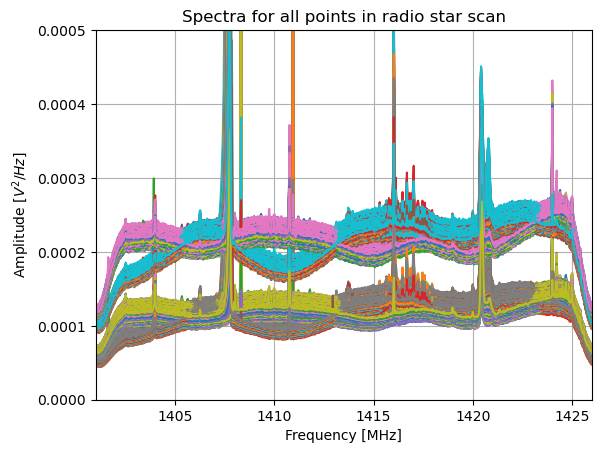

In [132]:
plt.figure()
for j in range(len(point_spectra)):
    for i in range(3):
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i])
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i])

plt.title("Spectra for all points in radio star scan")
plt.ylim([0,0.0005])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

## 4. Baseline flattening and initial calibrator shape estimation

estimate calibrator levels and flatten telescope baseline
note we do get the 3dB filter rolloff at the band edge like we should expect, and the calibrators are actualy extremely good at rejecting any of the rfi we see (almost none of it appears in the estimated calirator response)

In [134]:
### get calibrator deltas for all points and average
RHCP_cal = []
LHCP_cal = []

for i in range(num_points):

    RHCP_cal.append(point_spectra['RHCP'][i][1]- point_spectra['RHCP'][i][0])
    LHCP_cal.append(point_spectra['LHCP'][i][2]- point_spectra['LHCP'][i][0])

RHCP_cal = np.median(np.array(RHCP_cal),axis=0)
LHCP_cal = np.median(np.array(LHCP_cal),axis=0)

#RHCP_cal = np.mean(np.array(RHCP_cal),axis=0)
#LHCP_cal = np.mean(np.array(LHCP_cal),axis=0)

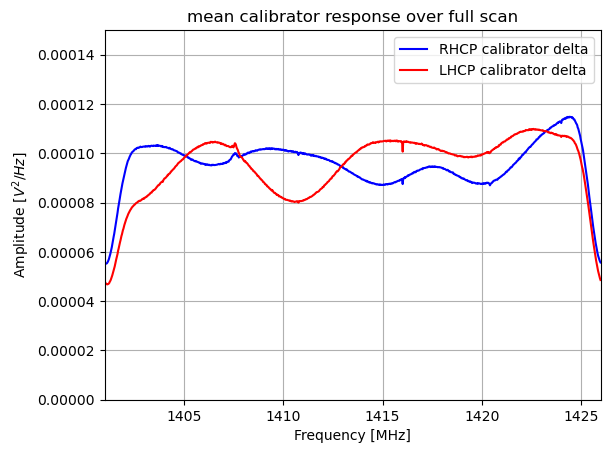

In [135]:
plt.figure()
#for j in range(len(point_spectra)):
    #for i in range(3):
plt.plot(point_spectra['frequencies'][0]/1e6,RHCP_cal,color='blue', label='RHCP calibrator delta')
plt.plot(point_spectra['frequencies'][0]/1e6,LHCP_cal,color='red', label='LHCP calibrator delta')

plt.title("mean calibrator response over full scan")
plt.ylim([0,0.00015])
plt.ylabel(r"Amplitude $[V^2/Hz]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.legend()
plt.grid()
plt.show()


### Divide spectra by nominal calibrator delta estimates and see what happens

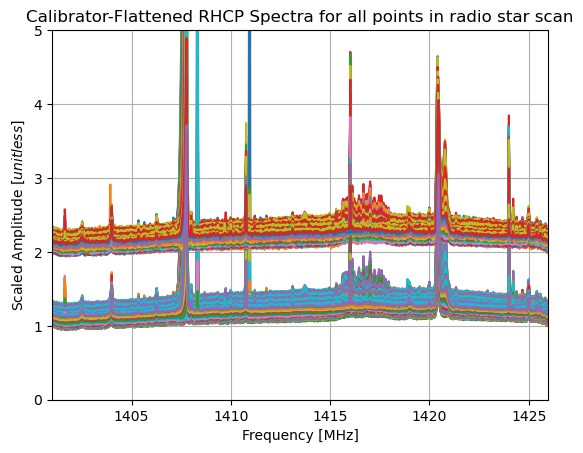

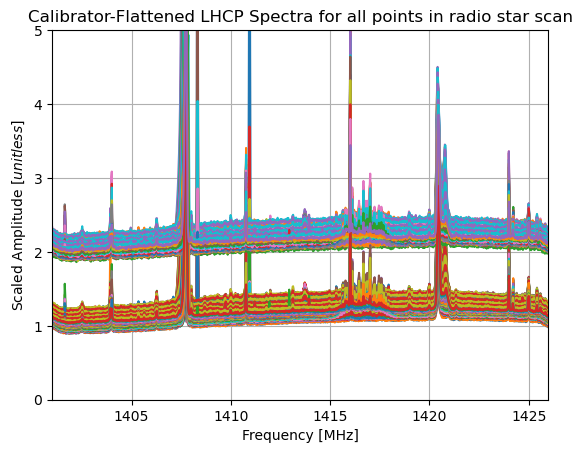

In [142]:
plt.figure()
for j in range(len(point_spectra)):
    for i in range(3):
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i]/RHCP_cal)
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened RHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()

plt.figure()
for j in range(len(point_spectra)):
    for i in range(3):
        #plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['RHCP'][j][i]/RHCP_cal)
        plt.plot(point_spectra['frequencies'][j]/1e6,point_spectra['LHCP'][j][i]/LHCP_cal)

plt.title("Calibrator-Flattened LHCP Spectra for all points in radio star scan")
plt.ylim([0,5])
plt.ylabel(r"Scaled Amplitude $[unitless]$")
plt.xlim([point_spectra.iloc[0]['frequencies'][0]/1e6, point_spectra.iloc[0]['frequencies'][-1]/1e6])
plt.xlabel("Frequency [MHz]")
plt.grid()
plt.show()